In [10]:
import pandas as pd

#Kaggle dataset Url= https://www.kaggle.com/datasets/abdullahmeo/car-price-pridiction

#Dataset describles vehicle brands with the features that impact the price for each vehicle.

#Seeking to determine which features impact the price more as well as where price may fluctuate in the future

# Please make sure the 'car_price_prediction_ (1).csv' file is uploaded to your Colab environment's root directory.
df = pd.read_csv("/car_price_prediction_ (1).csv")
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [11]:
df.describe

<bound method NDFrame.describe of       Car ID   Brand  Year  Engine Size Fuel Type Transmission  Mileage  \
0          1   Tesla  2016          2.3    Petrol       Manual   114832   
1          2     BMW  2018          4.4  Electric       Manual   143190   
2          3    Audi  2013          4.5  Electric       Manual   181601   
3          4   Tesla  2011          4.1    Diesel    Automatic    68682   
4          5    Ford  2009          2.6    Diesel       Manual   223009   
...      ...     ...   ...          ...       ...          ...      ...   
2495    2496    Audi  2020          2.4    Petrol    Automatic    22650   
2496    2497    Audi  2001          5.7    Hybrid       Manual    77701   
2497    2498    Ford  2021          1.1    Hybrid       Manual   272827   
2498    2499    Audi  2002          4.5    Diesel       Manual   229164   
2499    2500  Toyota  2005          4.6    Diesel    Automatic    80978   

     Condition     Price     Model  
0          New  26613.92   Model X  
1         Used  14679.61  5 Series  
2          New  44402.61        A4  
3          New  86374.33   Model Y  
4     Like New  73577.10   Mustang  
...        ...       ...       ...  
2495  Like New  61384.10        Q5  
2496  Like New  24710.35        A3  
2497  Like New  29902.45    Fiesta  
2498  Like New  46085.67        Q5  
2499      Used  16594.14      RAV4  

[2500 rows x 10 columns]>

In [12]:
df.shape

(2500, 10)

In [13]:
#Missing Values Analysis
df.isnull().sum()

,0
Car ID,0
Brand,0
Year,0
Engine Size,0
Fuel Type,0
Transmission,0
Mileage,0
Condition,0
Price,0
Model,0


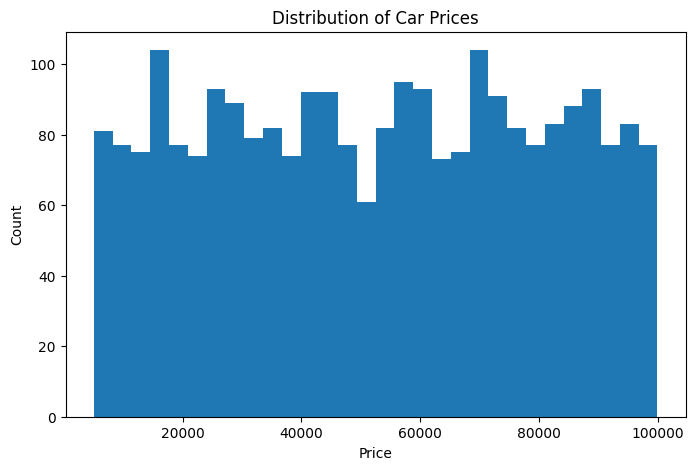

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['Price'], bins=30)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Distribution of Car Prices")
plt.show()

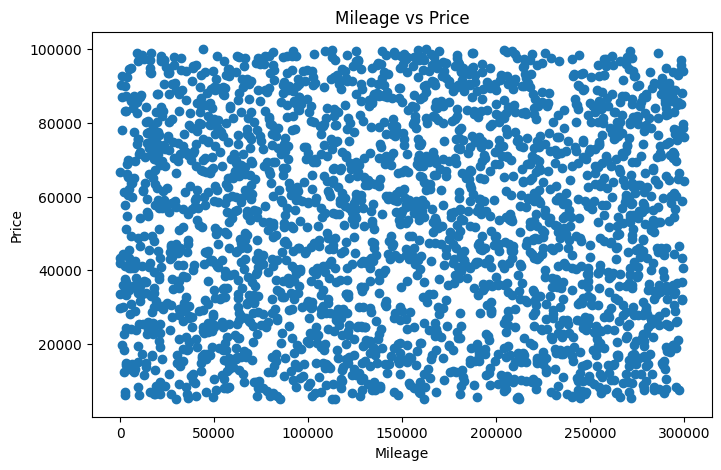

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(df['Mileage'], df['Price'])
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Mileage vs Price")
plt.show()

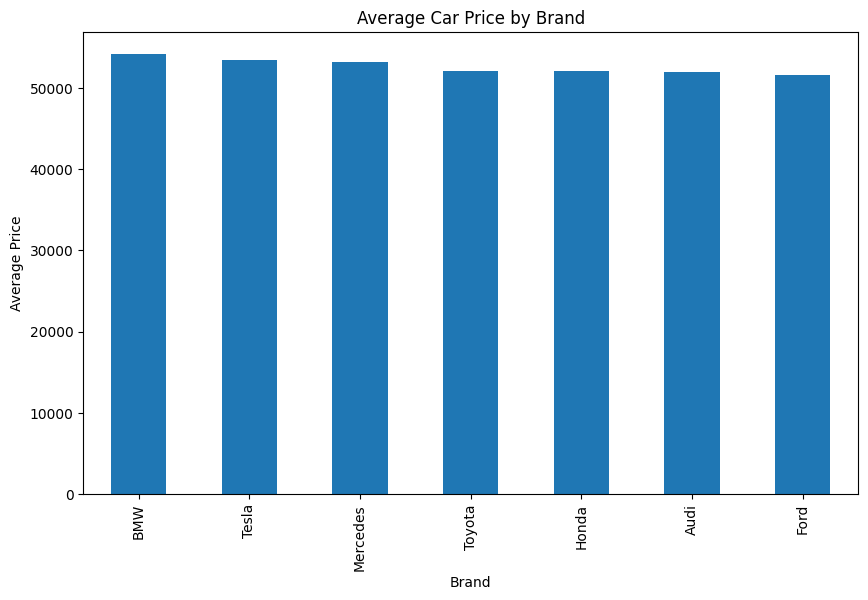

In [16]:
brand_prices = df.groupby('Brand')['Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
brand_prices.plot(kind='bar')
plt.ylabel("Average Price")
plt.title("Average Car Price by Brand")
plt.show()

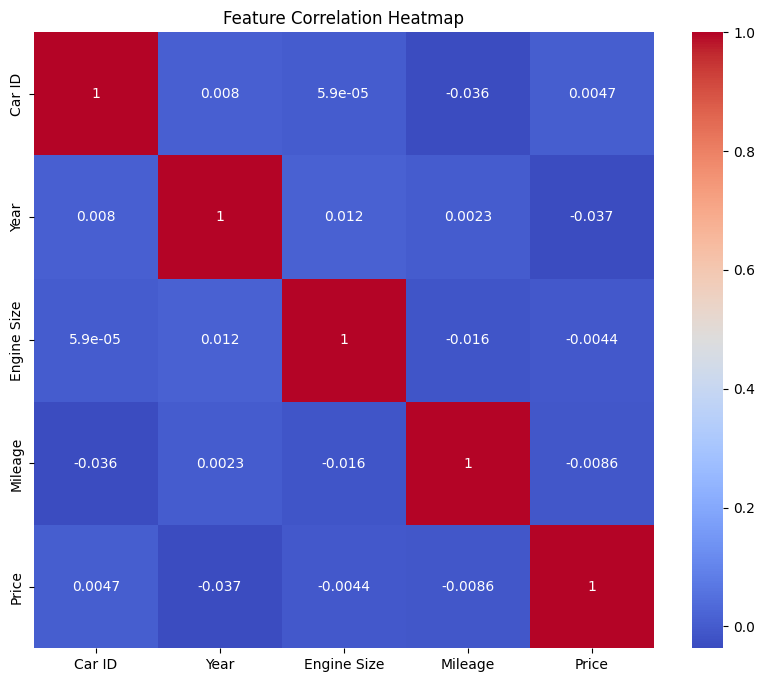

In [17]:
import seaborn as sns

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

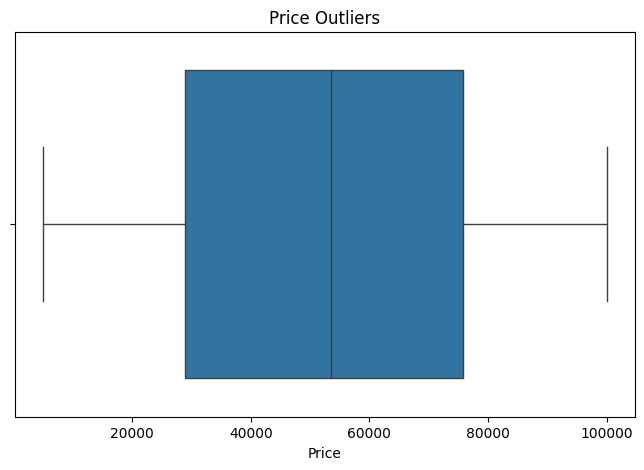

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Price'])
plt.title("Price Outliers")
plt.show()

In [22]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Brand'] = encoder.fit_transform(df['Brand'])
df['Fuel Type'] = encoder.fit_transform(df['Fuel Type'])
df['Transmission'] = encoder.fit_transform(df['Transmission'])

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = ['Mileage', 'Engine Size']

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

Based on industry knowledge and prior research, mileage, model year, and brand are expected to have the strongest influence on vehicle pricing.

Next Steps: Future work will involve training machine learning models such as Linear Regression, Random Forest, and XGBoost to compare predictive performance. Hyperparameter tuning and model explainability techniques such as SHAP may also be explored.